# 🏎️ CS-245 Machine Learning Project
## Notebook 1 — Data Preprocessing
**Project:** Predictive AI for Active Aerodynamics Efficiency and Driver Anomaly Analysis  
**Team:** Aero Intelligence | Hanan Majeed · Maha Mohsin · Anas Norani  
**Dataset:** 2026 F1 Japanese Grand Prix — Red Bull Telemetry (Suzuka Circuit)  
**Course:** CS-245 — Machine Learning | Instructor: Mam Nazia Pervaiz

---
### Notebook Scope
This notebook covers the complete data preprocessing pipeline:
1. Data loading & initial inspection
2. Missing value analysis & handling
3. Data type corrections & encoding
4. Outlier detection & handling
5. Physics-based feature engineering (3 derived features)
6. Feature scaling (StandardScaler)
7. Chronological train/test split (80/20)
8. Saving preprocessed artefacts for EDA and Modelling notebooks
---

## 0. Install & Import Libraries

In [49]:
# ── Standard library ─────────────────────────────────────────────────────────
import os
import warnings
warnings.filterwarnings('ignore')

# ── Data manipulation ─────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split

# ── Persistence ───────────────────────────────────────────────────────────────
import joblib

# ── Plot style (F1 dark aesthetic) ────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#1a1a2e',
    'axes.facecolor':   '#16213e',
    'axes.labelcolor':  '#e94560',
    'xtick.color':      '#ffffff',
    'ytick.color':      '#ffffff',
    'text.color':       '#ffffff',
    'axes.titlecolor':  '#e94560',
    'axes.edgecolor':   '#e94560',
    'grid.color':       '#2d2d44',
    'legend.facecolor': '#1a1a2e',
    'legend.edgecolor': '#e94560',
    'font.family':      'monospace',
})

F1_RED   = '#e94560'
F1_BLUE  = '#0f3460'
F1_WHITE = '#ffffff'
F1_GOLD  = '#f5a623'


# ── Create output folder for graphs ─────────────────────────────────────────
os.makedirs('graphs', exist_ok=True)

print('  Libraries loaded successfully.')

  Libraries loaded successfully.


---
## 1. Load Dataset

In [50]:
# ── Load the raw telemetry CSV ────────────────────────────────────────────────
# Update path if running locally (e.g. 'data/F1_2026_JapaneseGP_RedBull.csv')
CSV_PATH = 'F1_2026_JapaneseGP_RedBull__2_.csv'

df_raw = pd.read_csv(CSV_PATH)

print(f'Dataset shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print(f'Drivers present: {df_raw["Driver"].unique().tolist()}')
print(f'Lap range      : Lap {int(df_raw["LapNumber"].min())} → Lap {int(df_raw["LapNumber"].max())}')
df_raw.head()

Dataset shape  : 63,673 rows × 21 columns
Drivers present: ['VER', 'HAD']
Lap range      : Lap 2 → Lap 53


,Driver,LapNumber,Compound,Speed,RPM,nGear,Throttle,Brake,X,Y,...,Distance,Tire_Age_Laps,Time_Elapsed_Sec,Acceleration,Engine_Load,Elevation_Delta,Heavy_Braking,Active_Aero_State,High_Speed_Zone,Gear_Shift_Active
0,VER,2.0,MEDIUM,90.0,8570.194125,7,100.0,False,1585.455067,-514.526445,...,-0.000012,2.0,3926.237,0.0,8570.194125,0.000000,0,1,0,0
1,VER,2.0,MEDIUM,90.0,9131.754314,7,100.0,False,1626.000000,-562.000000,...,1.999939,2.0,3926.317,0.0,9131.754314,-1.627585,0,1,0,0
2,VER,2.0,MEDIUM,90.0,10395.264739,7,100.0,False,1718.000000,-670.000000,...,6.499942,2.0,3926.497,0.0,10395.264739,-4.000000,0,1,0,0
3,VER,2.0,MEDIUM,90.0,11020.000000,7,100.0,False,1763.887165,-723.796859,...,8.725000,2.0,3926.586,0.0,11020.000000,-2.242079,0,1,0,0
4,VER,2.0,MEDIUM,90.0,11095.000137,7,100.0,False,1800.000000,-766.000000,...,10.475077,2.0,3926.656,0.0,11095.000137,-1.757921,0,1,0,0


In [51]:
# ── Column overview ───────────────────────────────────────────────────────────
pd.set_option('display.max_rows', 30)
col_info = pd.DataFrame({
    'dtype':     df_raw.dtypes,
    'non_null':  df_raw.notna().sum(),
    'null':      df_raw.isna().sum(),
    'unique':    df_raw.nunique(),
    'sample':    df_raw.iloc[0]
})
col_info

,dtype,non_null,null,unique,sample
Driver,object,63673,0,2,VER
LapNumber,float64,63673,0,46,2.0
Compound,object,63673,0,2,MEDIUM
Speed,float64,63673,0,24784,90.0
RPM,float64,63673,0,32246,8570.194125
nGear,int64,63673,0,8,7
Throttle,float64,63673,0,10070,100.0
Brake,bool,63673,0,2,False
X,float64,63673,0,46099,1585.455067
Y,float64,63673,0,40229,-514.526445


---
## 2. Missing Value Analysis

In [52]:
# ── Quantify missing values ───────────────────────────────────────────────────
missing = df_raw.isna().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)

missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]

if missing_df.empty:
    print('  No missing values detected. Dataset is complete — no imputation required.')
else:
    print(f'  {len(missing_df)} columns have missing values:')
    print(missing_df)

    # Visualise
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.barh(missing_df.index, missing_df['Missing %'], color=F1_RED)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values per Column')
    plt.tight_layout()
    plt.savefig('graphs/missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()

  No missing values detected. Dataset is complete — no imputation required.


In [53]:
# ── Missing value strategy (if any exist) ─────────────────────────────────────
# The dataset is documented as complete (0 missing values per the project proposal).
# This block is a safety net; it will only run if nulls are detected.

df = df_raw.copy()  # Working copy — never mutate the raw dataframe

numeric_cols  = df.select_dtypes(include=[np.number]).columns.tolist()
object_cols   = df.select_dtypes(include=['object']).columns.tolist()

if df.isna().sum().sum() > 0:
    # Numeric → median imputation (robust to outliers)
    for col in numeric_cols:
        if df[col].isna().sum() > 0:
            median_val = df[col].median()
            df[col].fillna(median_val, inplace=True)
            print(f'  Filled {col} with median = {median_val:.4f}')

    # Categorical → mode imputation
    for col in object_cols:
        if df[col].isna().sum() > 0:
            mode_val = df[col].mode()[0]
            df[col].fillna(mode_val, inplace=True)
            print(f'  Filled {col} with mode = {mode_val}')
    print('  Imputation complete.')
else:
    print('  No imputation needed.')

print(f'\nWorking copy shape: {df.shape}')

  No imputation needed.

Working copy shape: (63673, 21)


---
## 3. Data Type Corrections & Categorical Encoding

In [54]:
# ── 3.1  Brake column: 'True'/'False' string → boolean → int ─────────────────
print('Brake unique values BEFORE:', df['Brake'].unique())

if df['Brake'].dtype == object:
    df['Brake'] = df['Brake'].map({'True': 1, 'False': 0}).astype(int)
elif df['Brake'].dtype == bool:
    df['Brake'] = df['Brake'].astype(int)

print('Brake unique values AFTER :', df['Brake'].unique())

Brake unique values BEFORE: [False  True]
Brake unique values AFTER : [0 1]


In [55]:
# ── 3.2  Compound: 'MEDIUM' / 'HARD' → binary integer (0 / 1) ────────────────
print('Compound unique values BEFORE:', df['Compound'].unique())

compound_map = {c: i for i, c in enumerate(sorted(df['Compound'].unique()))}
print('Encoding map:', compound_map)

df['Compound_Encoded'] = df['Compound'].map(compound_map).astype(int)

print('Compound_Encoded unique values:', df['Compound_Encoded'].unique())

Compound unique values BEFORE: ['MEDIUM' 'HARD']
Encoding map: {'HARD': 0, 'MEDIUM': 1}
Compound_Encoded unique values: [1 0]


In [56]:
# ── 3.3  Driver: kept as string for per-driver analysis; not in model features
print('Driver column dtypes:', df['Driver'].dtype)
print('Drivers:', df['Driver'].value_counts().to_dict())

# Confirm target & binary columns are integer
binary_cols = ['Active_Aero_State', 'High_Speed_Zone', 'Heavy_Braking', 'Gear_Shift_Active']
for col in binary_cols:
    df[col] = df[col].astype(int)

print('\n  All dtype corrections applied.')
df[binary_cols].dtypes

Driver column dtypes: object
Drivers: {'VER': 32789, 'HAD': 30884}

  All dtype corrections applied.


Active_Aero_State    int64
High_Speed_Zone      int64
Heavy_Braking        int64
Gear_Shift_Active    int64
dtype: object

---
## 4. Outlier Detection & Handling

In [57]:
# ── 4.1  IQR-based outlier detection on key continuous features ───────────────
key_features = ['Speed', 'RPM', 'Throttle', 'Acceleration', 'Engine_Load', 'Elevation_Delta']

outlier_summary = []
for col in key_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_summary.append({'Feature': col, 'Q1': Q1, 'Q3': Q3,
                             'Lower Fence': lower, 'Upper Fence': upper,
                             'Outlier Count': n_out,
                             'Outlier %': round(n_out / len(df) * 100, 2)})

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

        Feature           Q1           Q3   Lower Fence  Upper Fence  Outlier Count  Outlier %
          Speed   173.472732   272.000000     25.681830   419.790902              0       0.00
            RPM 10175.000000 11175.000000   8675.000000 12675.000000           1820       2.86
       Throttle    13.000000   100.000000   -117.500000   230.500000              0       0.00
   Acceleration    -0.810006     1.400000     -4.125014     4.715009          11798      18.53
    Engine_Load  1219.425427 11013.781272 -13472.108340 25705.315039              0       0.00
Elevation_Delta    -1.000516     1.131145     -4.198007     4.328637           8540      13.41


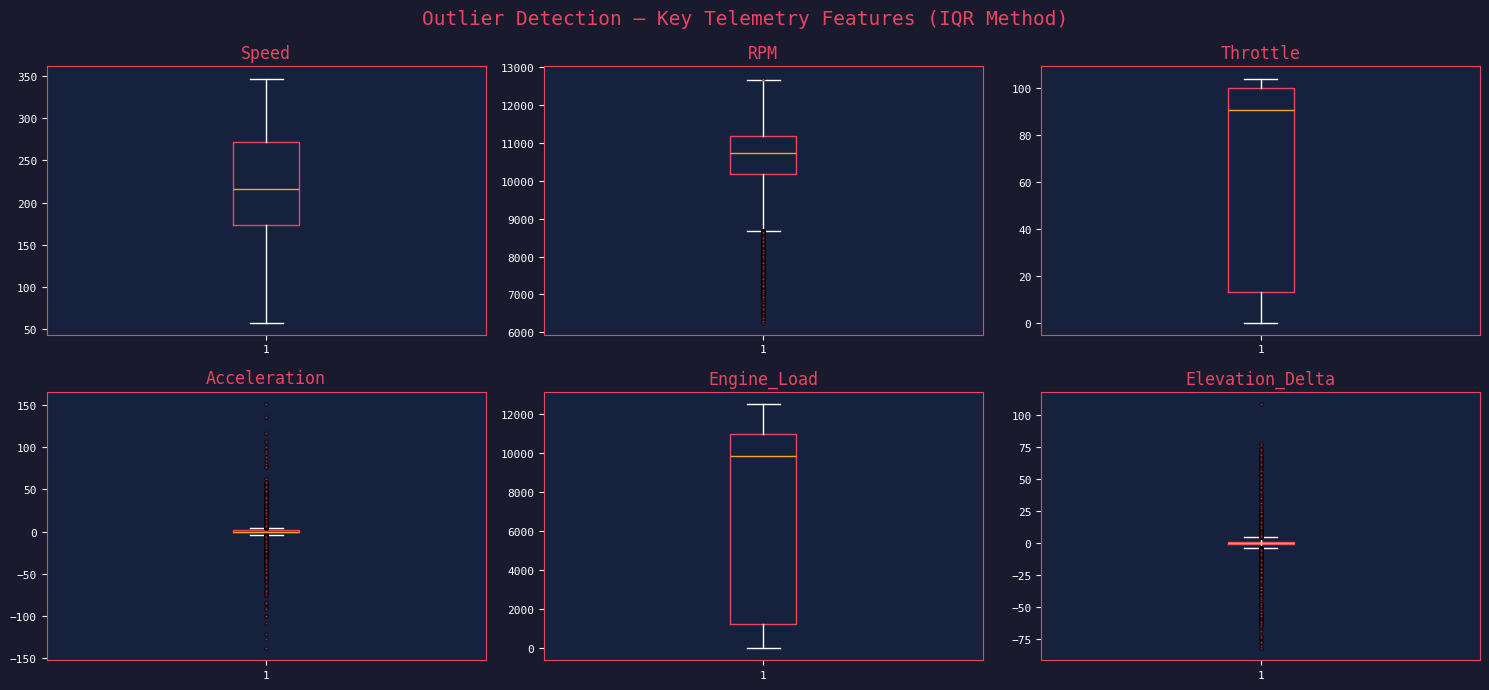

In [58]:
# ── 4.2  Visualise outliers with boxplots ─────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
fig.suptitle('Outlier Detection — Key Telemetry Features (IQR Method)', fontsize=14, color=F1_RED)

for ax, col in zip(axes.flat, key_features):
    ax.boxplot(df[col].dropna(), vert=True,
               boxprops=dict(color=F1_RED),
               whiskerprops=dict(color=F1_WHITE),
               capprops=dict(color=F1_WHITE),
               medianprops=dict(color=F1_GOLD),
               flierprops=dict(marker='o', markerfacecolor=F1_RED, markersize=2, alpha=0.5))
    ax.set_title(col)
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('graphs/outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

In [59]:
# ── 4.3  Outlier strategy: RETAIN (domain-justified) ─────────────────────────
# F1 telemetry naturally spans extreme ranges: 0 → 347 km/h, hard braking events,
# elevation changes at Suzuka, etc. These 'outliers' are physically real and
# critical for the model to learn correct aerodynamic transitions.
# We apply Winsorisation ONLY to Acceleration to clip non-physical spikes
# caused by GPS noise (values beyond ±5σ).

acc_mean = df['Acceleration'].mean()
acc_std  = df['Acceleration'].std()
lower_5s = acc_mean - 5 * acc_std
upper_5s = acc_mean + 5 * acc_std

before = len(df[(df['Acceleration'] < lower_5s) | (df['Acceleration'] > upper_5s)])
df['Acceleration'] = df['Acceleration'].clip(lower=lower_5s, upper=upper_5s)
after  = len(df[(df['Acceleration'] < lower_5s) | (df['Acceleration'] > upper_5s)])

print(f'Acceleration winsorisation: {before} extreme values clipped to ±5σ bounds.')
print(f'New Acceleration range: [{df["Acceleration"].min():.2f}, {df["Acceleration"].max():.2f}]')
print('\n  All other features retained — outliers are physically meaningful telemetry events.')

Acceleration winsorisation: 308 extreme values clipped to ±5σ bounds.
New Acceleration range: [-28.03, 28.04]

  All other features retained — outliers are physically meaningful telemetry events.


---
## 5. Physics-Based Feature Engineering

In [60]:
# ── 5.1  Kinetic Energy (MJ) ──────────────────────────────────────────────────
# KE = 0.5 × m × v²   where m = 798 kg (2026 F1 car mass), v in m/s
# Divided by 1,000,000 to express in MegaJoules for readability

MASS_KG = 798  # 2026 F1 car minimum weight

df['Kinetic_Energy_MJ'] = (
    0.5 * MASS_KG * (df['Speed'] / 3.6) ** 2
) / 1_000_000

print('Kinetic_Energy_MJ — sample statistics:')
print(df['Kinetic_Energy_MJ'].describe().round(4))

Kinetic_Energy_MJ — sample statistics:
count    63673.0000
mean         1.5969
std          0.8625
min          0.1036
25%          0.9265
50%          1.4364
75%          2.2777
max          3.7070
Name: Kinetic_Energy_MJ, dtype: float64


In [61]:
# ── 5.2  Longitudinal Force (N) ───────────────────────────────────────────────
# F = m × a   where a is in m/s²
# Acceleration column is in km/h/s → convert to m/s²: divide by 3.6

df['Longitudinal_Force_N'] = MASS_KG * (df['Acceleration'] / 3.6)

print('Longitudinal_Force_N — sample statistics:')
print(df['Longitudinal_Force_N'].describe().round(2))

Longitudinal_Force_N — sample statistics:
count    63673.00
mean         2.22
std       1075.19
min      -6213.35
25%       -179.55
50%          0.00
75%        310.33
max       6214.59
Name: Longitudinal_Force_N, dtype: float64


In [62]:
# ── 5.3  Energy Efficiency Ratio ──────────────────────────────────────────────
# EER = Speed / (Engine_Load + 1)
# +1 avoids division by zero when Engine_Load = 0
# High EER = efficient → low drag conditions → X-Mode likely beneficial

df['Energy_Efficiency_Ratio'] = df['Speed'] / (df['Engine_Load'] + 1)

print('Energy_Efficiency_Ratio — sample statistics:')
print(df['Energy_Efficiency_Ratio'].describe().round(4))

Energy_Efficiency_Ratio — sample statistics:
count    63673.0000
mean        36.2332
std         76.8443
min          0.0076
25%          0.0231
50%          0.0280
75%          0.1209
max        337.0000
Name: Energy_Efficiency_Ratio, dtype: float64


In [63]:
# ── 5.4  Speed Rolling Average (window = 10 rows) ─────────────────────────────
# Provides temporal context — smoothed speed trend used as a model feature

df['Speed_Rolling_Avg'] = (
    df.groupby('Driver')['Speed']
      .transform(lambda x: x.rolling(window=10, min_periods=1).mean())
)

print('Speed_Rolling_Avg — sample statistics:')
print(df['Speed_Rolling_Avg'].describe().round(2))

print(f'\n  Feature engineering complete.')
print(f'Total features now: {df.shape[1]} columns')

Speed_Rolling_Avg — sample statistics:
count    63673.00
mean       218.16
std         64.39
min         61.64
25%        174.60
50%        215.28
75%        271.56
max        346.22
Name: Speed_Rolling_Avg, dtype: float64

  Feature engineering complete.
Total features now: 26 columns


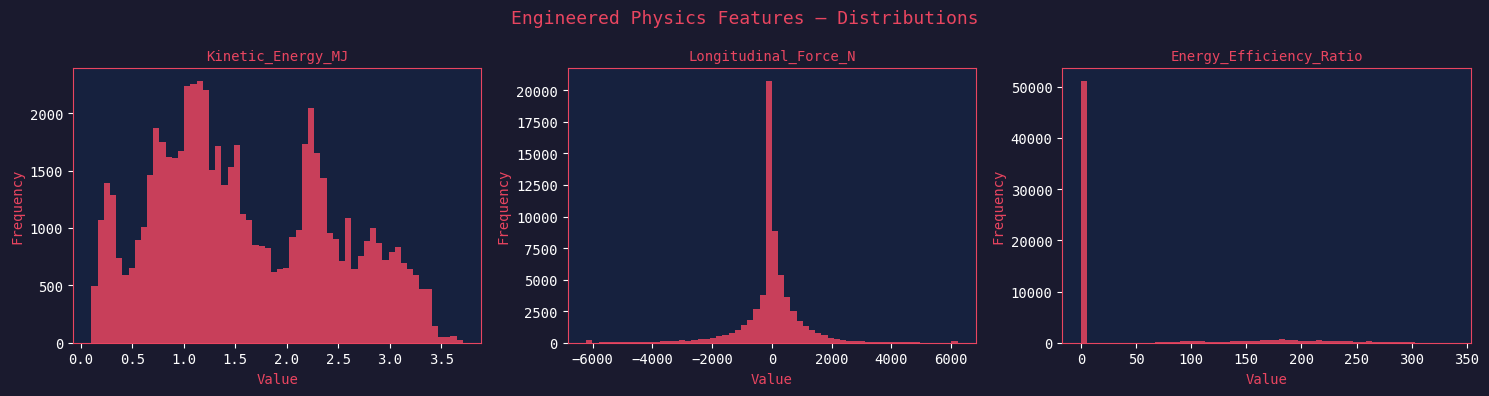

In [64]:
# ── 5.5  Visualise engineered features ───────────────────────────────────────
eng_features = ['Kinetic_Energy_MJ', 'Longitudinal_Force_N', 'Energy_Efficiency_Ratio']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Engineered Physics Features — Distributions', fontsize=13, color=F1_RED)

for ax, col in zip(axes, eng_features):
    ax.hist(df[col], bins=60, color=F1_RED, alpha=0.85, edgecolor='none')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('graphs/engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Physics-Based Optimal Aero Label Construction

**Key Design Principle:** Rather than training on the driver's *actual* aero activation (which contains human timing errors), we define a **physics-optimal ground truth** label.

**X-Mode (1) is optimal when ALL conditions are met:**
- Speed > 240 km/h
- Brake = False (not braking)
- nGear ≥ 6
- Heavy_Braking = 0
- High_Speed_Zone = 1
- Elevation_Delta > −3 (not descending steeply)

In [65]:
# ── Construct Optimal_Aero label ──────────────────────────────────────────────
df['Optimal_Aero'] = (
    (df['Speed'] > 240) &
    (df['Brake'] == 0) &
    (df['nGear'] >= 6) &
    (df['Heavy_Braking'] == 0) &
    (df['High_Speed_Zone'] == 1) &
    (df['Elevation_Delta'] > -3)
).astype(int)

# Distribution of Optimal_Aero
counts = df['Optimal_Aero'].value_counts()
pct    = (counts / len(df) * 100).round(1)

print('Optimal_Aero label distribution:')
print(f'  Z-Mode (0) — suboptimal : {counts[0]:,} rows ({pct[0]}%)')
print(f'  X-Mode (1) — optimal    : {counts[1]:,} rows ({pct[1]}%)')

# Comparison with driver's actual activation
driver_counts = df['Active_Aero_State'].value_counts()
d_pct = (driver_counts / len(df) * 100).round(1)
print('\nDriver\'s actual Active_Aero_State distribution:')
print(f'  Z-Mode (0): {driver_counts[0]:,} rows ({d_pct[0]}%)')
print(f'  X-Mode (1): {driver_counts[1]:,} rows ({d_pct[1]}%)')

Optimal_Aero label distribution:
  Z-Mode (0) — suboptimal : 54,290 rows (85.3%)
  X-Mode (1) — optimal    : 9,383 rows (14.7%)

Driver's actual Active_Aero_State distribution:
  Z-Mode (0): 35,829 rows (56.3%)
  X-Mode (1): 27,844 rows (43.7%)


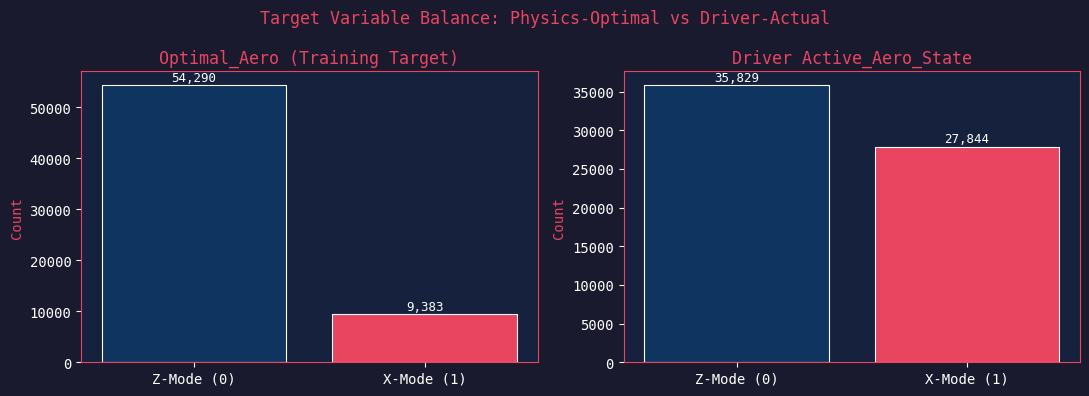

✅  Near-balanced dataset — no resampling (SMOTE / oversampling) required.


In [66]:
# ── Visualise label balance comparison ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
fig.suptitle('Target Variable Balance: Physics-Optimal vs Driver-Actual', color=F1_RED, fontsize=12)

for ax, col, title in zip(axes,
                          ['Optimal_Aero', 'Active_Aero_State'],
                          ['Optimal_Aero (Training Target)', 'Driver Active_Aero_State']):
    vals = df[col].value_counts()
    ax.bar(['Z-Mode (0)', 'X-Mode (1)'], vals.values,
           color=[F1_BLUE, F1_RED], edgecolor=F1_WHITE, linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel('Count')
    for i, v in enumerate(vals.values):
        ax.text(i, v + 200, f'{v:,}', ha='center', va='bottom', color=F1_WHITE, fontsize=9)

plt.tight_layout()
plt.savefig('graphs/target_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅  Near-balanced dataset — no resampling (SMOTE / oversampling) required.')

---
## 7. Define Final Feature Set

In [67]:
# ── 17 numeric features used by supervised & unsupervised models ──────────────
FEATURE_COLS = [
    'Speed', 'RPM', 'nGear', 'Throttle', 'Brake', 'Acceleration',
    'Engine_Load', 'Elevation_Delta', 'Tire_Age_Laps', 'Compound_Encoded',
    'Speed_Rolling_Avg', 'Kinetic_Energy_MJ', 'Longitudinal_Force_N',
    'Energy_Efficiency_Ratio', 'High_Speed_Zone', 'Heavy_Braking', 'Gear_Shift_Active'
]

# After K-Means clustering (Notebook 3), Track_Zone will be added making it 18
TARGET_COL          = 'Optimal_Aero'          # Physics-derived ground truth
DRIVER_ACTUAL_COL   = 'Active_Aero_State'     # For post-training deviation analysis

print(f'Feature columns ({len(FEATURE_COLS)}): {FEATURE_COLS}')
print(f'Target column             : {TARGET_COL}')
print(f'Driver-actual column      : {DRIVER_ACTUAL_COL}')

# Sanity check — all features exist
assert all(col in df.columns for col in FEATURE_COLS), '❌  Some feature columns are missing!'
print('\n  All feature columns validated.')

Feature columns (17): ['Speed', 'RPM', 'nGear', 'Throttle', 'Brake', 'Acceleration', 'Engine_Load', 'Elevation_Delta', 'Tire_Age_Laps', 'Compound_Encoded', 'Speed_Rolling_Avg', 'Kinetic_Energy_MJ', 'Longitudinal_Force_N', 'Energy_Efficiency_Ratio', 'High_Speed_Zone', 'Heavy_Braking', 'Gear_Shift_Active']
Target column             : Optimal_Aero
Driver-actual column      : Active_Aero_State

  All feature columns validated.


---
## 8. Feature Scaling (StandardScaler)

In [68]:
# ── StandardScaler: zero mean, unit variance ──────────────────────────────────
# MANDATORY for:
#   • K-Means (Euclidean distance is scale-sensitive)
#   • Logistic Regression (gradient-based convergence)
# Applied uniformly to Random Forest for pipeline consistency.

scaler = StandardScaler()

X_raw    = df[FEATURE_COLS].values
X_scaled = scaler.fit_transform(X_raw)
y        = df[TARGET_COL].values
y_actual = df[DRIVER_ACTUAL_COL].values

print('Scaled feature matrix shape:', X_scaled.shape)
print(f'Mean (should be ~0): {X_scaled.mean(axis=0).round(4)}')
print(f'Std  (should be ~1): {X_scaled.std(axis=0).round(4)}')

# Also store unscaled for interpretability
X_df_scaled = pd.DataFrame(X_scaled, columns=FEATURE_COLS, index=df.index)

print('\n  StandardScaler fitted and applied.')

Scaled feature matrix shape: (63673, 17)
Mean (should be ~0): [-0. -0. -0. -0. -0.  0.  0.  0. -0. -0.  0. -0.  0. -0.  0. -0.  0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

  StandardScaler fitted and applied.


---
## 9. Chronological Train/Test Split (80/20)

In [69]:
# ── CHRONOLOGICAL split — NO random shuffling ─────────────────────────────────
# Time-series data must be split forward in time to prevent data leakage.
# The dataset is already sorted by Driver → LapNumber → Time_Elapsed_Sec.

SPLIT_RATIO = 0.80
split_idx   = int(len(X_scaled) * SPLIT_RATIO)

X_train = X_scaled[:split_idx]
X_test  = X_scaled[split_idx:]
y_train = y[:split_idx]
y_test  = y[split_idx:]

# Keep metadata aligned
df_train = df.iloc[:split_idx].copy()
df_test  = df.iloc[split_idx:].copy()

print(f'Total samples : {len(X_scaled):,}')
print(f'Train samples : {len(X_train):,} ({len(X_train)/len(X_scaled)*100:.1f}%)')
print(f'Test samples  : {len(X_test):,}  ({len(X_test)/len(X_scaled)*100:.1f}%)')
print(f'\nTrain label balance — Z:{(y_train==0).sum():,} | X:{(y_train==1).sum():,}')
print(f'Test  label balance — Z:{(y_test==0).sum():,}  | X:{(y_test==1).sum():,}')

Total samples : 63,673
Train samples : 50,938 (80.0%)
Test samples  : 12,735  (20.0%)

Train label balance — Z:43,578 | X:7,360
Test  label balance — Z:10,712  | X:2,023


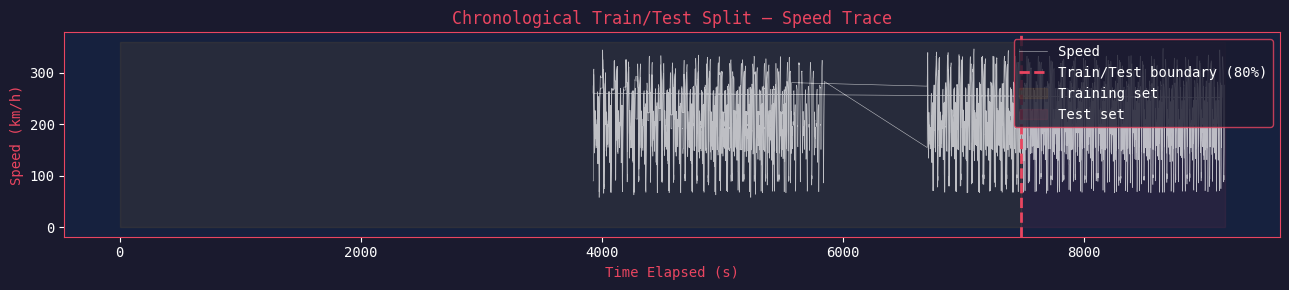

In [70]:
# ── Visualise the chronological split boundary ────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(df['Time_Elapsed_Sec'].values, df['Speed'].values,
        color=F1_WHITE, lw=0.4, alpha=0.7, label='Speed')
ax.axvline(df['Time_Elapsed_Sec'].iloc[split_idx], color=F1_RED, lw=2,
           linestyle='--', label=f'Train/Test boundary (80%)')
ax.fill_betweenx([0, 360], 0,
                 df['Time_Elapsed_Sec'].iloc[split_idx],
                 alpha=0.08, color=F1_GOLD, label='Training set')
ax.fill_betweenx([0, 360],
                 df['Time_Elapsed_Sec'].iloc[split_idx],
                 df['Time_Elapsed_Sec'].max(),
                 alpha=0.08, color=F1_RED, label='Test set')
ax.set_xlabel('Time Elapsed (s)')
ax.set_ylabel('Speed (km/h)')
ax.set_title('Chronological Train/Test Split — Speed Trace')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('graphs/train_test_split.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Save Preprocessed Artefacts

In [71]:
# ── Save all artefacts for Notebooks 2 (EDA) and 3 (Modelling) ───────────────
os.makedirs('artefacts', exist_ok=True)

# Full preprocessed dataframe (for EDA)
df.to_csv('artefacts/df_preprocessed.csv', index=False)

# Train/Test arrays
np.save('artefacts/X_train.npy', X_train)
np.save('artefacts/X_test.npy',  X_test)
np.save('artefacts/y_train.npy', y_train)
np.save('artefacts/y_test.npy',  y_test)

# Scaler (fit on training data)
joblib.dump(scaler, 'artefacts/standard_scaler.pkl')

# Feature column list
joblib.dump(FEATURE_COLS, 'artefacts/feature_cols.pkl')

# Driver-actual labels for post-training deviation analysis
np.save('artefacts/y_actual_full.npy', y_actual)
df_train.to_csv('artefacts/df_train.csv', index=False)
df_test.to_csv('artefacts/df_test.csv',   index=False)

print('  Artefacts saved to artefacts/ directory:')
for f in sorted(os.listdir('artefacts')):
    size = os.path.getsize(f'artefacts/{f}') / 1024
    print(f'   {f:<35} {size:>8.1f} KB')

  Artefacts saved to artefacts/ directory:
   X_test.npy                            1691.5 KB
   X_train.npy                           6765.3 KB
   df_final_with_anomalies.csv          17499.5 KB
   df_preprocessed.csv                  14912.5 KB
   df_test.csv                           3006.8 KB
   df_train.csv                         11906.1 KB
   feature_cols.pkl                         0.3 KB
   model_comparison_table.csv               0.4 KB
   standard_scaler.pkl                      1.0 KB
   y_actual_full.npy                      497.6 KB
   y_test.npy                              99.6 KB
   y_train.npy                            398.1 KB


---
## 11. Preprocessing Summary Report

In [72]:
print('=' * 62)
print('  PREPROCESSING PIPELINE — SUMMARY REPORT')
print('=' * 62)
print(f'  Raw dataset shape         : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} cols')
print(f'  Final dataset shape       : {df.shape[0]:,} rows × {df.shape[1]} cols')
print(f'  Missing values            : 0 (dataset complete)')
print(f'  Outlier strategy          : Retain (physically valid)')
print(f'  Winsorised               : Acceleration (±5σ)')
print(f'  Encoding applied          : Brake→int | Compound→0/1')
print(f'  Engineered features       : Kinetic_Energy_MJ')
print(f'                              Longitudinal_Force_N')
print(f'                              Energy_Efficiency_Ratio')
print(f'                              Speed_Rolling_Avg')
print(f'  Optimal_Aero label        : Physics-derived (not driver-actual)')
print(f'  Training features         : {len(FEATURE_COLS)} columns')
print(f'  Scaler                    : StandardScaler (zero-mean, unit-var)')
print(f'  Split type                : Chronological (no shuffle)')
print(f'  Train size                : {len(X_train):,} rows (80%)')
print(f'  Test size                 : {len(X_test):,} rows (20%)')
print('=' * 62)
print('    Ready for EDA (Notebook 2) and Modelling (Notebook 3)')
print('=' * 62)

  PREPROCESSING PIPELINE — SUMMARY REPORT
  Raw dataset shape         : 63,673 rows × 21 cols
  Final dataset shape       : 63,673 rows × 27 cols
  Missing values            : 0 (dataset complete)
  Outlier strategy          : Retain (physically valid)
  Winsorised               : Acceleration (±5σ)
  Encoding applied          : Brake→int | Compound→0/1
  Engineered features       : Kinetic_Energy_MJ
                              Longitudinal_Force_N
                              Energy_Efficiency_Ratio
                              Speed_Rolling_Avg
  Optimal_Aero label        : Physics-derived (not driver-actual)
  Training features         : 17 columns
  Scaler                    : StandardScaler (zero-mean, unit-var)
  Split type                : Chronological (no shuffle)
  Train size                : 50,938 rows (80%)
  Test size                 : 12,735 rows (20%)
    Ready for EDA (Notebook 2) and Modelling (Notebook 3)
